In [1]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import time
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import yfinance as yf
from scipy.stats import pearsonr
import warnings

warnings.filterwarnings("ignore")

nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [2]:
raw_output_file = 'all_companies_news_raw.csv'
cleaned_output_file = 'all_companies_news_cleaned.csv'
output_file = 'all_companies_news_with_sentiment.csv'
merged_output_file = 'merged_sentiment_stock_data_v4.csv'
tickers = ['AAPL', 'META', 'MSFT', 'NVDA', 'TSLA']

df_raw = pd.read_csv(raw_output_file)
df_cleaned = df_raw.copy()

In [3]:
df_cleaned.dropna(subset=['Headline', 'Date'], inplace=True)
df_cleaned['Headline'] = df_cleaned['Headline'].astype(str)

original_date_format = "%d %b, %Y, %I.%M %p IST"
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'], format=original_date_format, errors='coerce')
df_cleaned.dropna(subset=['Date'], inplace=True)
df_cleaned.sort_values(by='Date', inplace=True)

def clean_text_basic(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_cleaned['Cleaned_Headline'] = df_cleaned['Headline'].apply(clean_text_basic)

df_cleaned['Date_Only'] = df_cleaned['Date'].dt.date
duplicates_subset = ['Date_Only', 'company', 'Headline']
df_cleaned.drop_duplicates(subset=duplicates_subset, keep='first', inplace=True)
df_cleaned.drop(columns=['Date_Only'], inplace=True)

columns_to_save = ['Source', 'company', 'Headline', 'Date', 'Cleaned_Headline']
existing_columns = [col for col in columns_to_save if col in df_cleaned.columns]
df_cleaned[existing_columns].to_csv(cleaned_output_file, index=False, date_format='%Y-%m-%d %H:%M:%S')

In [4]:
lemmatizer = WordNetLemmatizer()
analyzer = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

df = pd.read_csv(cleaned_output_file, parse_dates=['Date'])
df.sort_values('Date', inplace=True)
df.dropna(subset=['Headline', 'Date', 'company'], inplace=True)
df['Headline'] = df['Headline'].astype(str)

def get_vader_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0
    scores = analyzer.polarity_scores(text)
    return scores['compound']

df['Sentiment_Score'] = df['Headline'].apply(get_vader_sentiment)

def categorize_vader_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment_Category'] = df['Sentiment_Score'].apply(categorize_vader_sentiment)
df.to_csv(output_file, index=False)

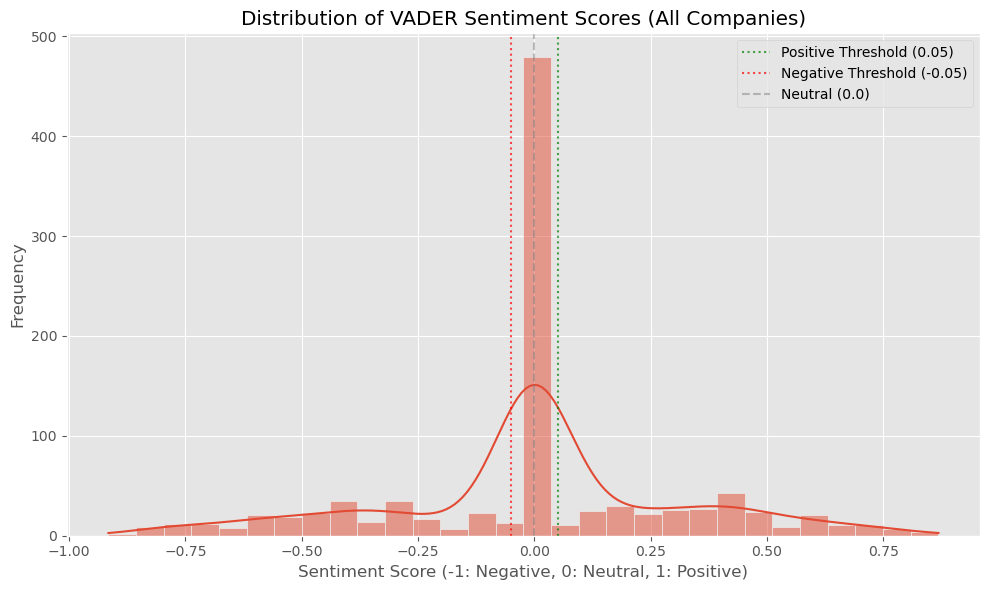

In [5]:
plt.style.use('ggplot')
plt.figure(figsize=(10, 6))
sns.histplot(df['Sentiment_Score'], kde=True, bins=30)
plt.title('Distribution of VADER Sentiment Scores (All Companies)')
plt.xlabel('Sentiment Score (-1: Negative, 0: Neutral, 1: Positive)')
plt.ylabel('Frequency')
plt.axvline(x=0.05, color='green', linestyle=':', alpha=0.7, label='Positive Threshold (0.05)')
plt.axvline(x=-0.05, color='red', linestyle=':', alpha=0.7, label='Negative Threshold (-0.05)')
plt.axvline(x=0, color='grey', linestyle='--', alpha=0.5, label='Neutral (0.0)')
plt.legend()
plt.tight_layout()
plt.savefig('vader_sentiment_distribution_overall.png')
plt.show()

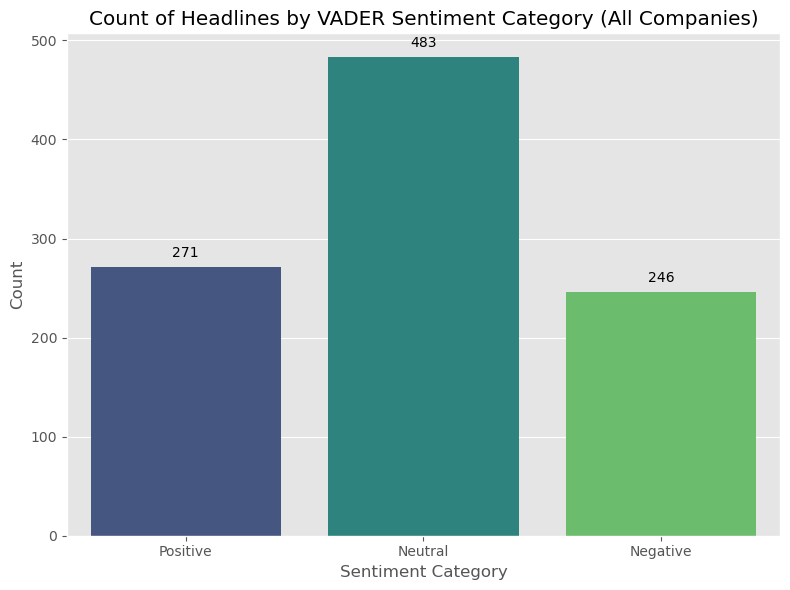

In [6]:
plt.figure(figsize=(8, 6))
category_order = ['Positive', 'Neutral', 'Negative']
present_categories = [cat for cat in category_order if cat in df['Sentiment_Category'].unique()]
ax = sns.countplot(x='Sentiment_Category', data=df, order=present_categories, palette='viridis')
plt.title('Count of Headlines by VADER Sentiment Category (All Companies)')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.savefig('vader_sentiment_category_counts_overall.png')
plt.show()

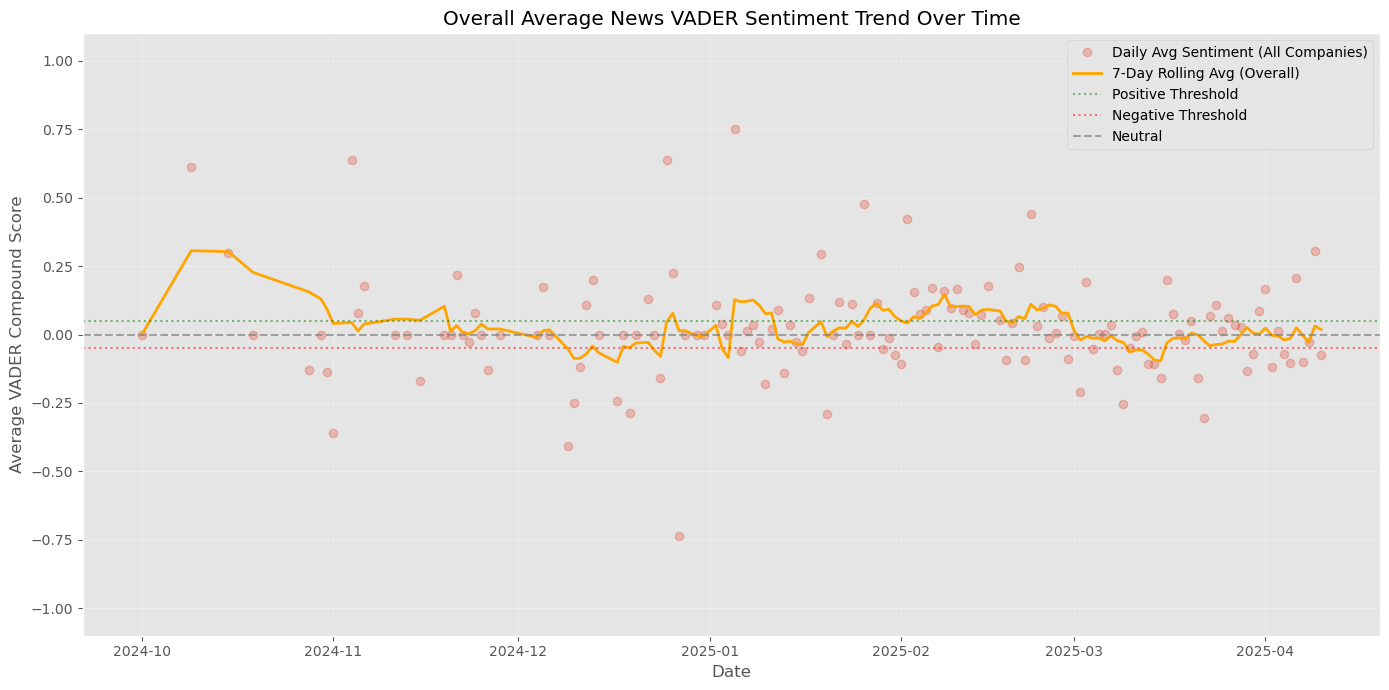

In [7]:
plt.figure(figsize=(14, 7))
daily_avg_sentiment = df.groupby(df['Date'].dt.date)['Sentiment_Score'].mean()
rolling_avg = daily_avg_sentiment.rolling(window=7, min_periods=1).mean()
plt.plot(daily_avg_sentiment.index, daily_avg_sentiment.values, marker='o', linestyle='', alpha=0.3, label='Daily Avg Sentiment (All Companies)')
plt.plot(rolling_avg.index, rolling_avg.values, linestyle='-', color='orange', linewidth=2, label='7-Day Rolling Avg (Overall)')
plt.title('Overall Average News VADER Sentiment Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Average VADER Compound Score')
plt.axhline(y=0.05, color='green', linestyle=':', alpha=0.5, label='Positive Threshold')
plt.axhline(y=-0.05, color='red', linestyle=':', alpha=0.5, label='Negative Threshold')
plt.axhline(y=0, color='grey', linestyle='--', alpha=0.7, label='Neutral')
plt.ylim(-1.1, 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('vader_sentiment_trend_overall.png')
plt.show()

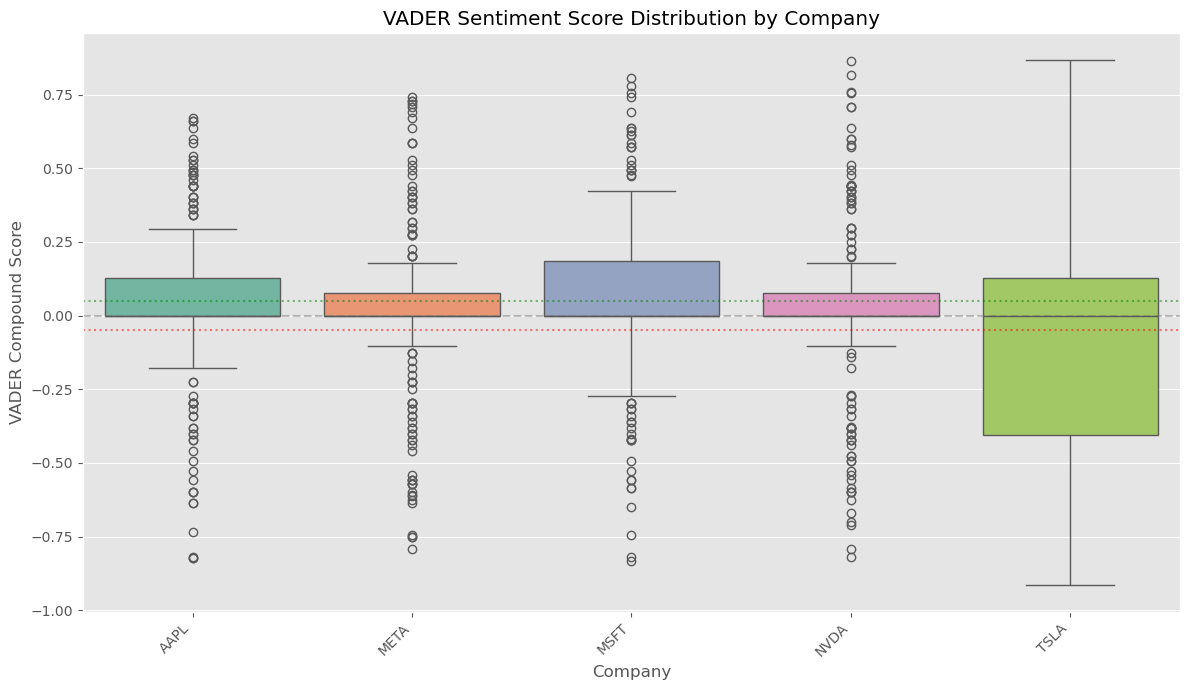

In [8]:
plt.figure(figsize=(12, 7))
company_order = sorted(df['company'].unique())
sns.boxplot(x='company', y='Sentiment_Score', data=df, order=company_order, palette='Set2')
plt.title('VADER Sentiment Score Distribution by Company')
plt.xlabel('Company')
plt.ylabel('VADER Compound Score')
plt.axhline(y=0.05, color='green', linestyle=':', alpha=0.5)
plt.axhline(y=-0.05, color='red', linestyle=':', alpha=0.5)
plt.axhline(y=0, color='grey', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('vader_sentiment_boxplot_by_company.png')
plt.show()

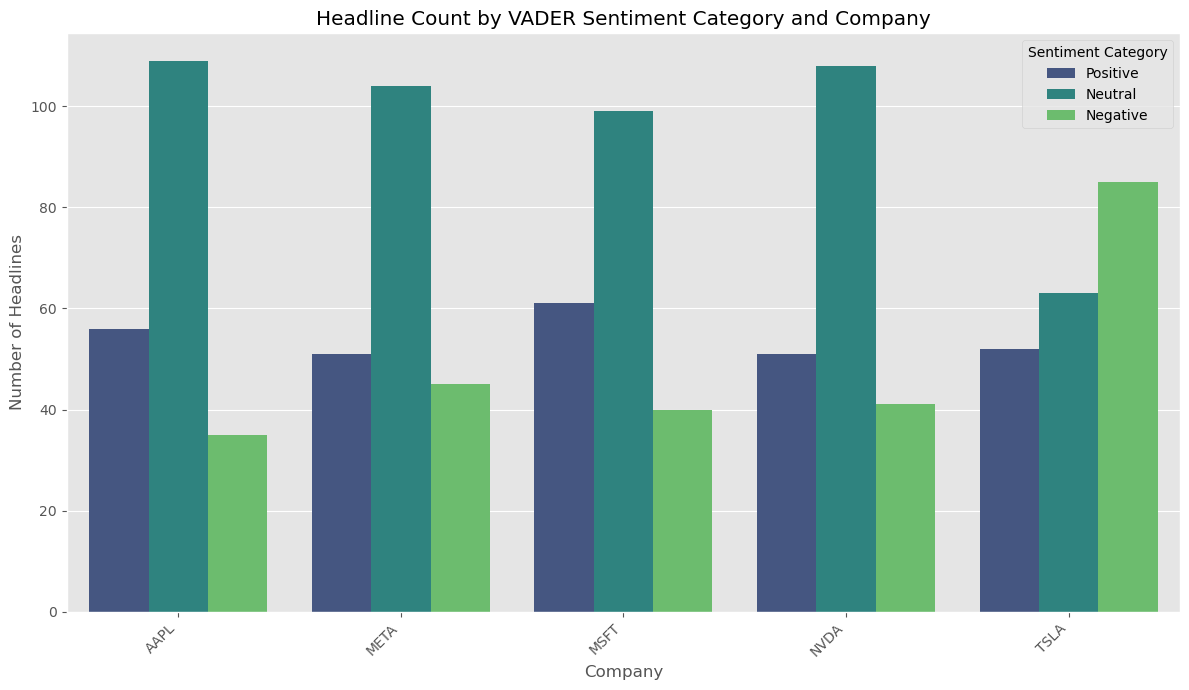

In [9]:
plt.figure(figsize=(12, 7))
sns.countplot(x='company', hue='Sentiment_Category', data=df, order=company_order, hue_order=category_order, palette='viridis')
plt.title('Headline Count by VADER Sentiment Category and Company')
plt.xlabel('Company')
plt.ylabel('Number of Headlines')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment Category')
plt.tight_layout()
plt.savefig('vader_sentiment_countplot_by_company.png')
plt.show()

In [10]:
df_sentiment = pd.read_csv(output_file, parse_dates=['Date'])

min_date = df_sentiment['Date'].min().strftime('%Y-%m-%d')
max_date = df_sentiment['Date'].max().strftime('%Y-%m-%d')
start_date = (df_sentiment['Date'].min() - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
end_date = (df_sentiment['Date'].max() + pd.Timedelta(days=2)).strftime('%Y-%m-%d')

stock_data_raw = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)

if isinstance(stock_data_raw.columns, pd.MultiIndex):
    stock_data_processed = stock_data_raw.stack(level=1).rename_axis(['Date', 'Ticker']).reset_index()
else:
    stock_data_processed = stock_data_raw.reset_index()

if 'Ticker' in stock_data_processed.columns:
    stock_data_filtered = stock_data_processed[stock_data_processed['Ticker'].str.upper().isin(tickers)].copy()
    stock_data_filtered = stock_data_filtered.rename(columns={'Ticker': 'company'})
else:
    stock_data_filtered = stock_data_processed.copy()
    if len(tickers) == 1 and 'company' not in stock_data_filtered.columns:
        stock_data_filtered['company'] = tickers[0]

stock_data_filtered.columns = stock_data_filtered.columns.str.lower()

[*********************100%***********************]  5 of 5 completed


In [11]:
price_col = 'close'
rename_map = {
    price_col: 'adj_close',
    'volume': 'stock_volume'
}
actual_rename_map = {k: v for k, v in rename_map.items() if k in stock_data_filtered.columns}
stock_data_filtered = stock_data_filtered.rename(columns=actual_rename_map)

stock_data_filtered = stock_data_filtered.sort_values(['company', 'date'])

stock_data_filtered['stock_return'] = stock_data_filtered.groupby('company')['adj_close'].pct_change().fillna(0)
stock_data_filtered['next_day_stock_return'] = stock_data_filtered.groupby('company')['stock_return'].shift(-1).fillna(0)

columns_to_select = ['date', 'company', 'adj_close', 'stock_volume', 'stock_return', 'next_day_stock_return']
if 'open' in stock_data_filtered.columns: columns_to_select.insert(3,'open')
if 'high' in stock_data_filtered.columns: columns_to_select.insert(4,'high')
if 'low' in stock_data_filtered.columns: columns_to_select.insert(5,'low')
if 'close' in stock_data_filtered.columns and 'close' not in ['adj_close','stock_volume','stock_return','next_day_stock_return']:
    columns_to_select.insert(6,'close')

existing_cols = [col for col in columns_to_select if col in stock_data_filtered.columns]
stock_data_final = stock_data_filtered[existing_cols].copy()

stock_data_final['date'] = pd.to_datetime(stock_data_final['date']).dt.date

In [12]:
df_sentiment['date_only'] = pd.to_datetime(df_sentiment['Date']).dt.date
daily_sentiment = df_sentiment.groupby(['date_only', 'company']).agg(
    avg_sentiment_score=('Sentiment_Score', 'mean'),
    num_headlines=('Headline', 'count'),
    std_sentiment_score=('Sentiment_Score', 'std')
).reset_index()
daily_sentiment['std_sentiment_score'].fillna(0, inplace=True)
daily_sentiment.rename(columns={'date_only': 'date'}, inplace=True)

df_merged = pd.merge(daily_sentiment, stock_data_final, on=['date', 'company'], how='inner')
df_merged.dropna(subset=['stock_return', 'next_day_stock_return'], inplace=True)
df_merged.to_csv(merged_output_file, index=False, float_format='%.4f')

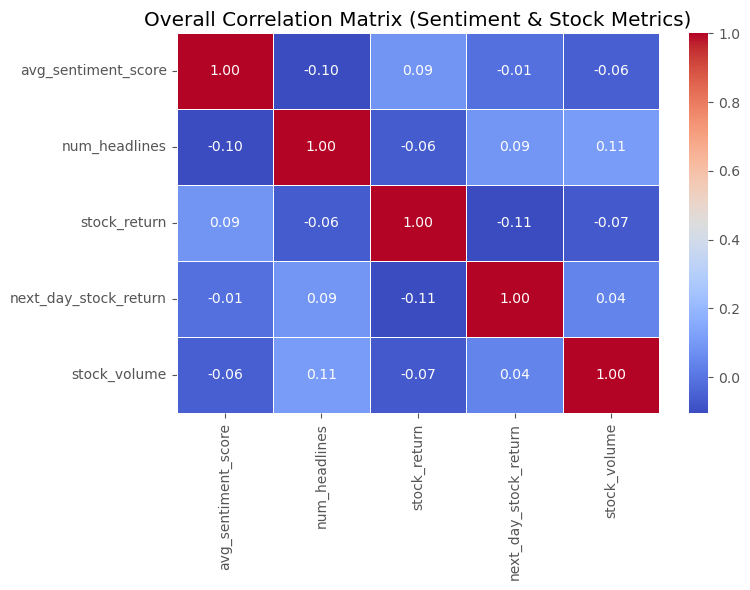

In [13]:
overall_corr_cols = ['avg_sentiment_score', 'num_headlines', 'stock_return', 'next_day_stock_return', 'stock_volume']
overall_corr_cols_exist = [col for col in overall_corr_cols if col in df_merged.columns]
numeric_merged_df = df_merged[overall_corr_cols_exist].select_dtypes(include=np.number)

overall_correlation_matrix = numeric_merged_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(overall_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Overall Correlation Matrix (Sentiment & Stock Metrics)')
plt.tight_layout()
plt.savefig('correlation_heatmap_overall.png')
plt.show()

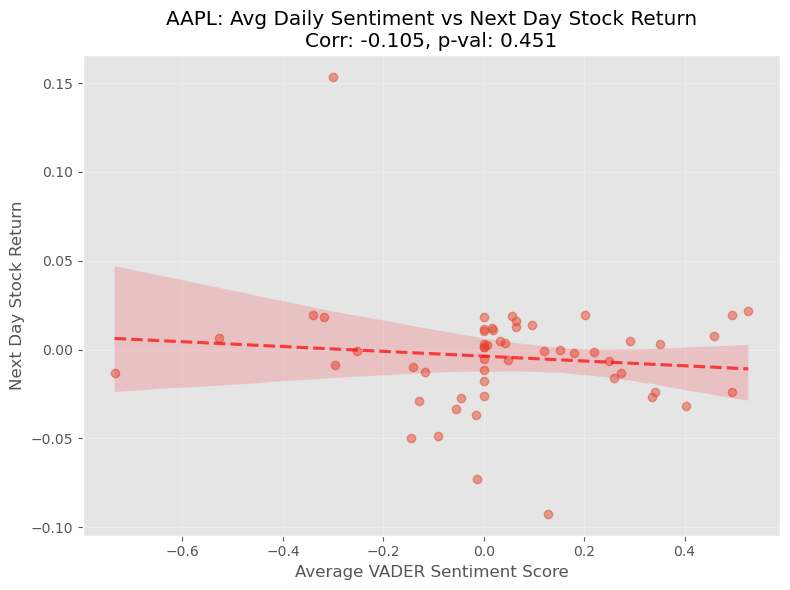

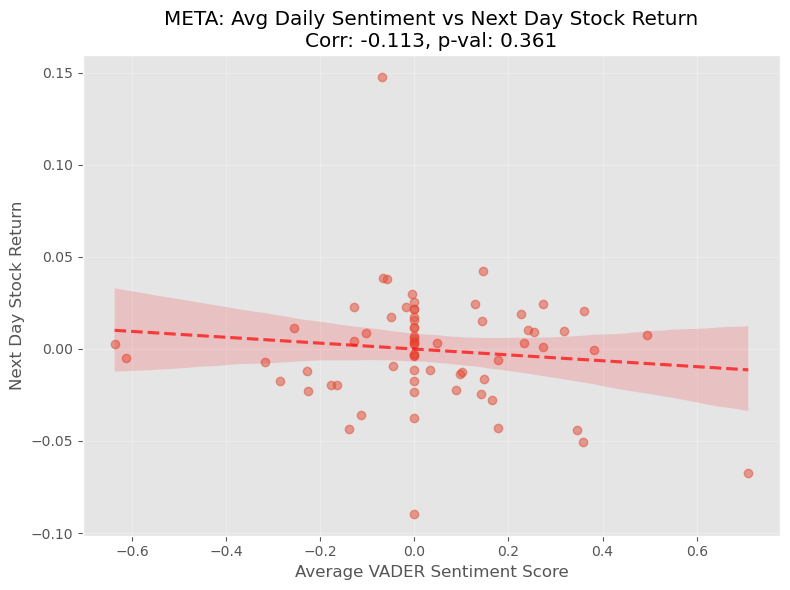

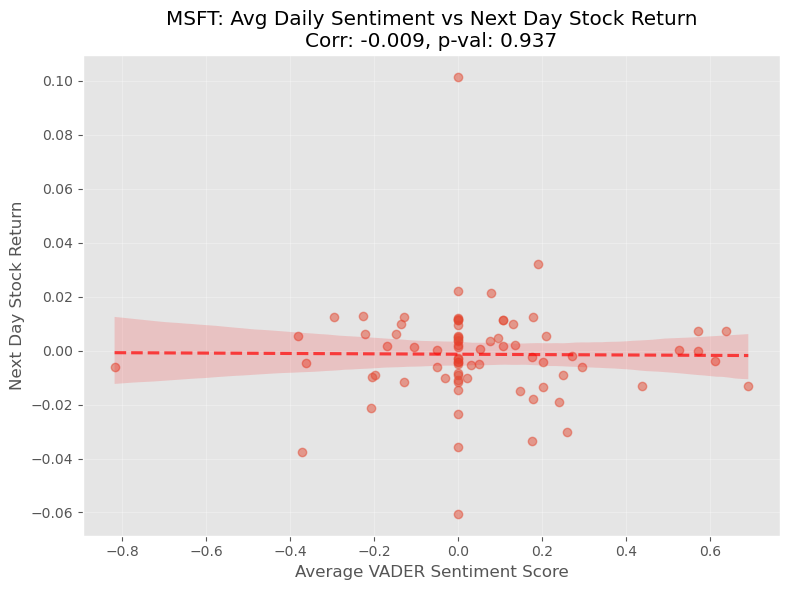

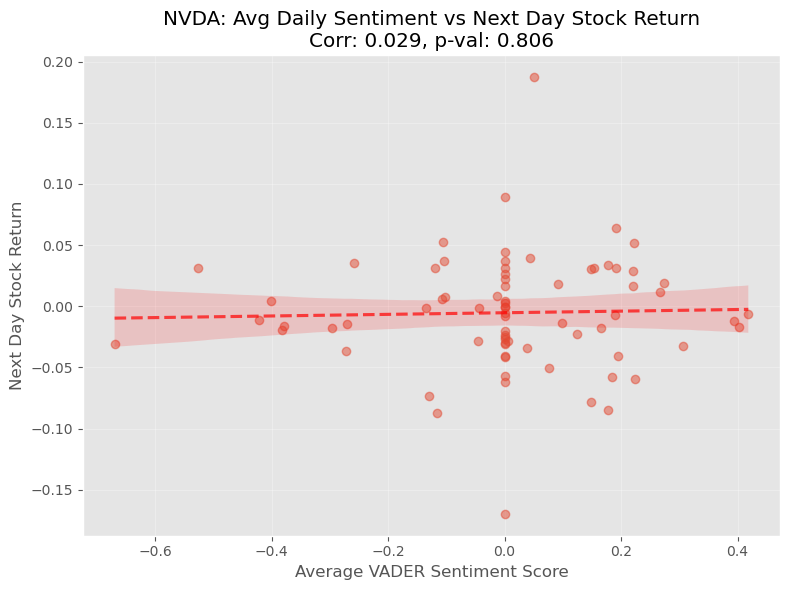

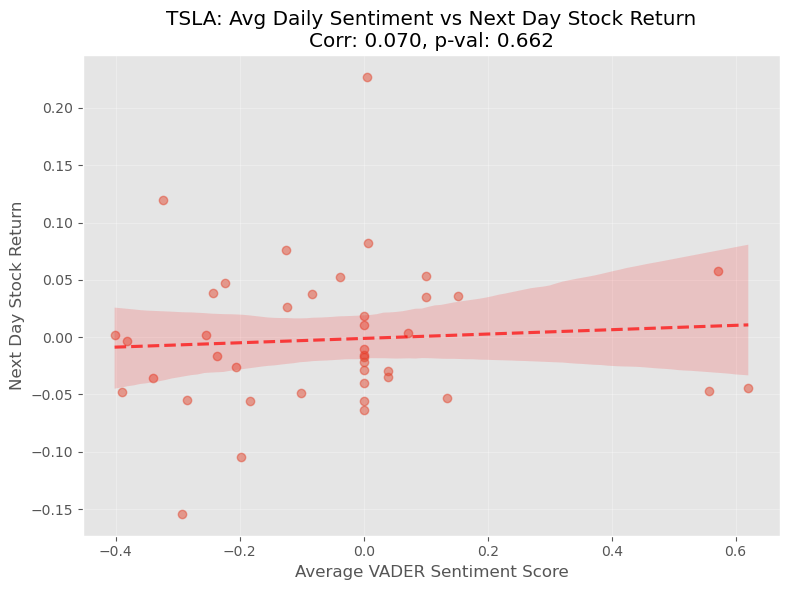

In [14]:
for company in tickers:
    df_company = df_merged[df_merged['company'] == company].copy()
    if len(df_company) > 1:
        company_corr_cols = ['avg_sentiment_score', 'num_headlines', 'stock_return', 'next_day_stock_return', 'stock_volume']
        company_corr_cols_exist = [col for col in company_corr_cols if col in df_company.columns]

        essential_cols = ['avg_sentiment_score', 'stock_return', 'next_day_stock_return']
        if all(col in company_corr_cols_exist for col in essential_cols):
            numeric_company_df = df_company[company_corr_cols_exist].select_dtypes(include=np.number)
            if not numeric_company_df.empty and len(numeric_company_df.columns) >= 2:
                company_correlation_matrix = numeric_company_df.corr()

                df_company_clean = df_company[essential_cols].dropna()
                if len(df_company_clean) > 1:
                    corr_sent_return, p_sent_return = pearsonr(df_company_clean['avg_sentiment_score'], df_company_clean['stock_return'])
                    corr_sent_next_return, p_sent_next_return = pearsonr(df_company_clean['avg_sentiment_score'], df_company_clean['next_day_stock_return'])

                    plt.figure(figsize=(8, 6))
                    sns.regplot(x='avg_sentiment_score', y='next_day_stock_return', data=df_company_clean,
                                line_kws={'color': 'red', 'linestyle': '--', 'alpha':0.7}, scatter_kws={'alpha':0.5})
                    plt.title(f'{company}: Avg Daily Sentiment vs Next Day Stock Return\nCorr: {corr_sent_next_return:.3f}, p-val: {p_sent_next_return:.3f}')
                    plt.xlabel('Average VADER Sentiment Score')
                    plt.ylabel('Next Day Stock Return')
                    plt.grid(True, alpha=0.3)
                    plt.tight_layout()
                    plt.savefig(f'scatter_sentiment_vs_next_return_{company}.png')
                    plt.show()